<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day09_practice3_YOLO11_%EC%B6%94%EB%A1%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# YOLO11 첫 추론

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 8.5 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import urllib.request, os # 인터넷 다운로드

In [5]:
BUS_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
if not os.path.exists("bus.jpg"):
    urllib.request.urlretrieve(BUS_URL, "bus.jpg")
    print("bus.jpg 다운로드 완료 (재실행 시 재사용)")

bus.jpg 다운로드 완료 (재실행 시 재사용)


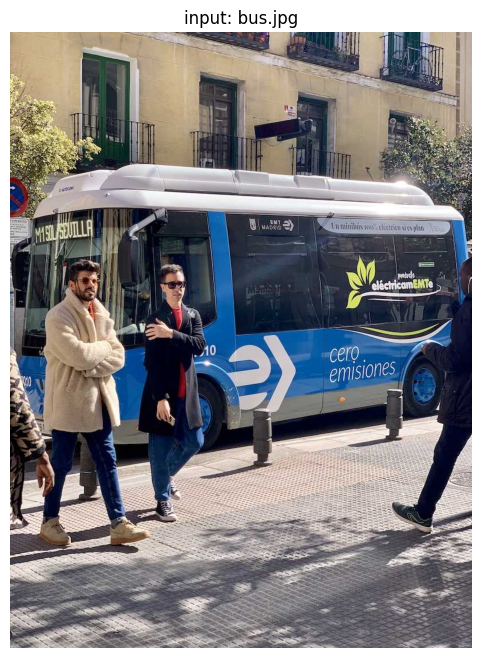

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("bus.jpg")
plt.figure(figsize=(6,8))
plt.imshow(img)
plt.axis("off")
plt.title("input: bus.jpg")
plt.show()

In [7]:
# 셀 1. 감지
model = YOLO("yolo11n.pt") # GitHub(ultralytics/assets releases)에서 자동 다운로드, 모델 크기 라인업: n < s < m < l < x (클수록 정확, 느림)
results = model("bus.jpg")
r = results[0]

# 사전학습(pretraining): 큰 데이터셋으로 모델을 미리 학습시켜 두는 과정
# 사전학습 모델(pretrained model): 그 과정을 거쳐 이미 학습이 끝난 모델(가중치) ← yolo11n.pt

# COCO 데이터셋(이미지33만장, 80종 클래스)으로 사전학습 된 모델


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 8.1ms
Speed: 102.3ms preprocess, 8.1ms inference, 46.9ms postprocess per image at shape (1, 3, 640, 480)


In [9]:
print("감지된 물체:", len(r.boxes), "개")

감지된 물체: 5 개


In [11]:
print(r.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.], device='cuda:0')
conf: tensor([0.9402, 0.8882, 0.8783, 0.8558, 0.6219], device='cuda:0')
data: tensor([[3.8327e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02, 9.4015e-01, 5.0000e+00],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02, 8.8822e-01, 0.0000e+00],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0419e+02, 8.7825e-01, 0.0000e+00],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02, 8.5577e-01, 0.0000e+00],
        [2.1713e-02, 5.5607e+02, 6.8886e+01, 8.7236e+02, 6.2192e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[400.0136, 478.8883, 792.3619, 499.0480],
        [740.4135, 636.7728, 138.7925, 483.8794],
        [143.3527, 651.8801, 191.8959, 504.6298],
        [283.7633, 634.5622, 121.4086, 451.7470],
        [ 34.4536, 714.2139,  68.8638, 316.2907]], device='cuda:0')
xywhn: tensor([[0.4938, 0.4434, 0.97

In [12]:
r.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [13]:
# 셀 2. 결과 객체 해부 - boxes 안에 전부 있다
print("[결과 해부]")
for box in r.boxes:
  cls_id = int(box.cls)
  name = r.names[cls_id]
  conf = float(box.conf)
  xyxy = box.xyxy[0].tolist()
  print(f"{name:8s} conf {conf:.3f} | xyxy {[round(v) for v in xyxy]}")

[결과 해부]
bus      conf 0.940 | xyxy [4, 229, 796, 728]
person   conf 0.888 | xyxy [671, 395, 810, 879]
person   conf 0.878 | xyxy [47, 400, 239, 904]
person   conf 0.856 | xyxy [223, 409, 344, 860]
person   conf 0.622 | xyxy [0, 556, 69, 872]


In [15]:
# 셀 3. 시각화 - 박스 그린 사진 저장
r.save(filename = "plot1_detected.jpg")

'plot1_detected.jpg'

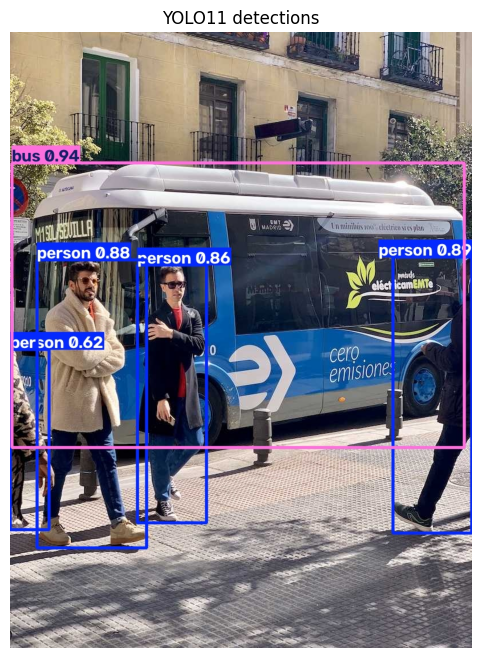

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("plot1_detected.jpg")
plt.figure(figsize=(6,8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO11 detections")
plt.show()

In [17]:
# 셀 4. conf 문턱 조절
for conf_thr in [0.25, 0.6, 0.9]:
  n = len(model("bus.jpg", conf=conf_thr, verbose=False)[0].boxes) # 결과[0].boxes의 개수를 len()으로 셈. verbose=False: 진행 로그 끔
  print(f"conf ≥ {conf_thr} → 감지 {n}개")
# 문턱을 올리면 확실한 것만 남는다 (precision ↑up, recall ↓down)

conf ≥ 0.25 → 감지 5개
conf ≥ 0.6 → 감지 5개
conf ≥ 0.9 → 감지 1개


In [19]:
# 셀 5. '도로위험감지 앱' 형식으로 변환
detections = []
for box in r.boxes:
  x1, y1, x2, y2 = box.xyxyn[0].tolist() #비율 좌표
  detections.append({
      "type": r.names[int(box.cls)],
      "confidence": round(float(box.conf), 3),
      "box": {"x1": round(x1, 3), "y1": round(y1, 3), "x2": round(x2, 3), "y2": round(y2, 3)},
  })

import json
print(json.dumps(detections[:2], ensure_ascii=False, indent=2)) # json.dumps: 객체를 JSON문자열로

[
  {
    "type": "bus",
    "confidence": 0.94,
    "box": {
      "x1": 0.005,
      "y1": 0.212,
      "x2": 0.983,
      "y2": 0.674
    }
  },
  {
    "type": "person",
    "confidence": 0.888,
    "box": {
      "x1": 0.828,
      "y1": 0.366,
      "x2": 1.0,
      "y2": 0.814
    }
  }
]
